In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df_test= pd.read_csv('/content/drive/MyDrive/MS Research/Sem 1/ML/Phase 2 Project/Dataset/data-smoker/test_dataset.csv')
df_train= pd.read_csv('/content/drive/MyDrive/MS Research/Sem 1/ML/Phase 2 Project/Dataset/data-smoker/train_dataset.csv')

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38984 entries, 0 to 38983
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  38984 non-null  int64  
 1   height(cm)           38984 non-null  int64  
 2   weight(kg)           38984 non-null  int64  
 3   waist(cm)            38984 non-null  float64
 4   eyesight(left)       38984 non-null  float64
 5   eyesight(right)      38984 non-null  float64
 6   hearing(left)        38984 non-null  int64  
 7   hearing(right)       38984 non-null  int64  
 8   systolic             38984 non-null  int64  
 9   relaxation           38984 non-null  int64  
 10  fasting blood sugar  38984 non-null  int64  
 11  Cholesterol          38984 non-null  int64  
 12  triglyceride         38984 non-null  int64  
 13  HDL                  38984 non-null  int64  
 14  LDL                  38984 non-null  int64  
 15  hemoglobin           38984 non-null 

In [ ]:
print(f"Number of duplicate rows in df_train: {df_train.duplicated().sum()}")
df_train.drop_duplicates(inplace=True)
print(f"Number of rows in df_train after dropping duplicates: {df_train.shape[0]}")

# Check for missing values
missing_values_count = df_train.isnull().sum().sum()
if missing_values_count == 0:
    print("No missing values found in df_train.")
else:
    print(f"Number of missing values in df_train: {missing_values_count}")

Number of duplicate rows in df_train: 5517
Number of rows in df_train after dropping duplicates: 33467
No missing values found in df_train.


## feature Engineering

In [ ]:
def create_features(df):
    df['BMI'] = df['weight(kg)'] / ((df['height(cm)'] / 100) ** 2)
    df['HW_Ratio'] = df['height(cm)'] / df['waist(cm)']
    df['HA_Ratio'] = df['height(cm)'] / df['age']
    return df

df_train = create_features(df_train)
df_test = create_features(df_test)

In [ ]:
def massive_feature(df, ignore_list):
    features = [feat for feat in df.columns if feat not in ignore_list]

    for idx1, col_one in enumerate(features):
        for idx2, col_two in enumerate(features):
            if idx1 < idx2:
                df[col_one +'_to_'+ col_two] = df[col_one] / df[col_two]
    return df

# The original 'id' and 'is_original' columns are not present in df_train/df_test.
# Adapting ignore_list to existing columns and the target variable 'smoking'.
df_train = massive_feature(df_train, ignore_list = ['smoking', 'dental caries','hearing(left)','hearing(right)'])
df_test = massive_feature(df_test, ignore_list = ['dental caries','hearing(left)','hearing(right)'])


In [ ]:
def detect_outliers_iqr(df):
    outlier_counts = {}
    numerical_cols = df.select_dtypes(include=np.number).columns

    for column in numerical_cols:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
        outlier_counts[column] = len(outliers)
    return outlier_counts

outliers_df_train = detect_outliers_iqr(df_train)

print("Outliers in df_train (IQR method):")
for col, count in outliers_df_train.items():
    if count > 0:
        print(f"  {col}: {count} outliers")
    else:
        print(f"  {col}: No outliers")


Outliers in df_train (IQR method):
  age: 184 outliers
  height(cm): 155 outliers
  weight(kg): 127 outliers
  waist(cm): 329 outliers
  eyesight(left): 810 outliers
  eyesight(right): 823 outliers
  hearing(left): 849 outliers
  hearing(right): 872 outliers
  systolic: 414 outliers
  relaxation: 427 outliers
  fasting blood sugar: 1987 outliers
  Cholesterol: 373 outliers
  triglyceride: 1412 outliers
  HDL: 595 outliers
  LDL: 403 outliers
  hemoglobin: 476 outliers
  Urine protein: 1844 outliers
  serum creatinine: 1905 outliers
  AST: 1800 outliers
  ALT: 2255 outliers
  Gtp: 2901 outliers
  dental caries: 7185 outliers
  smoking: No outliers
  BMI: 578 outliers
  HW_Ratio: 327 outliers
  HA_Ratio: 2693 outliers
  age_to_height(cm): 381 outliers
  age_to_weight(kg): 251 outliers
  age_to_waist(cm): 146 outliers
  age_to_eyesight(left): 2354 outliers
  age_to_eyesight(right): 2448 outliers
  age_to_systolic: 210 outliers
  age_to_relaxation: 414 outliers
  age_to_fasting blood sugar

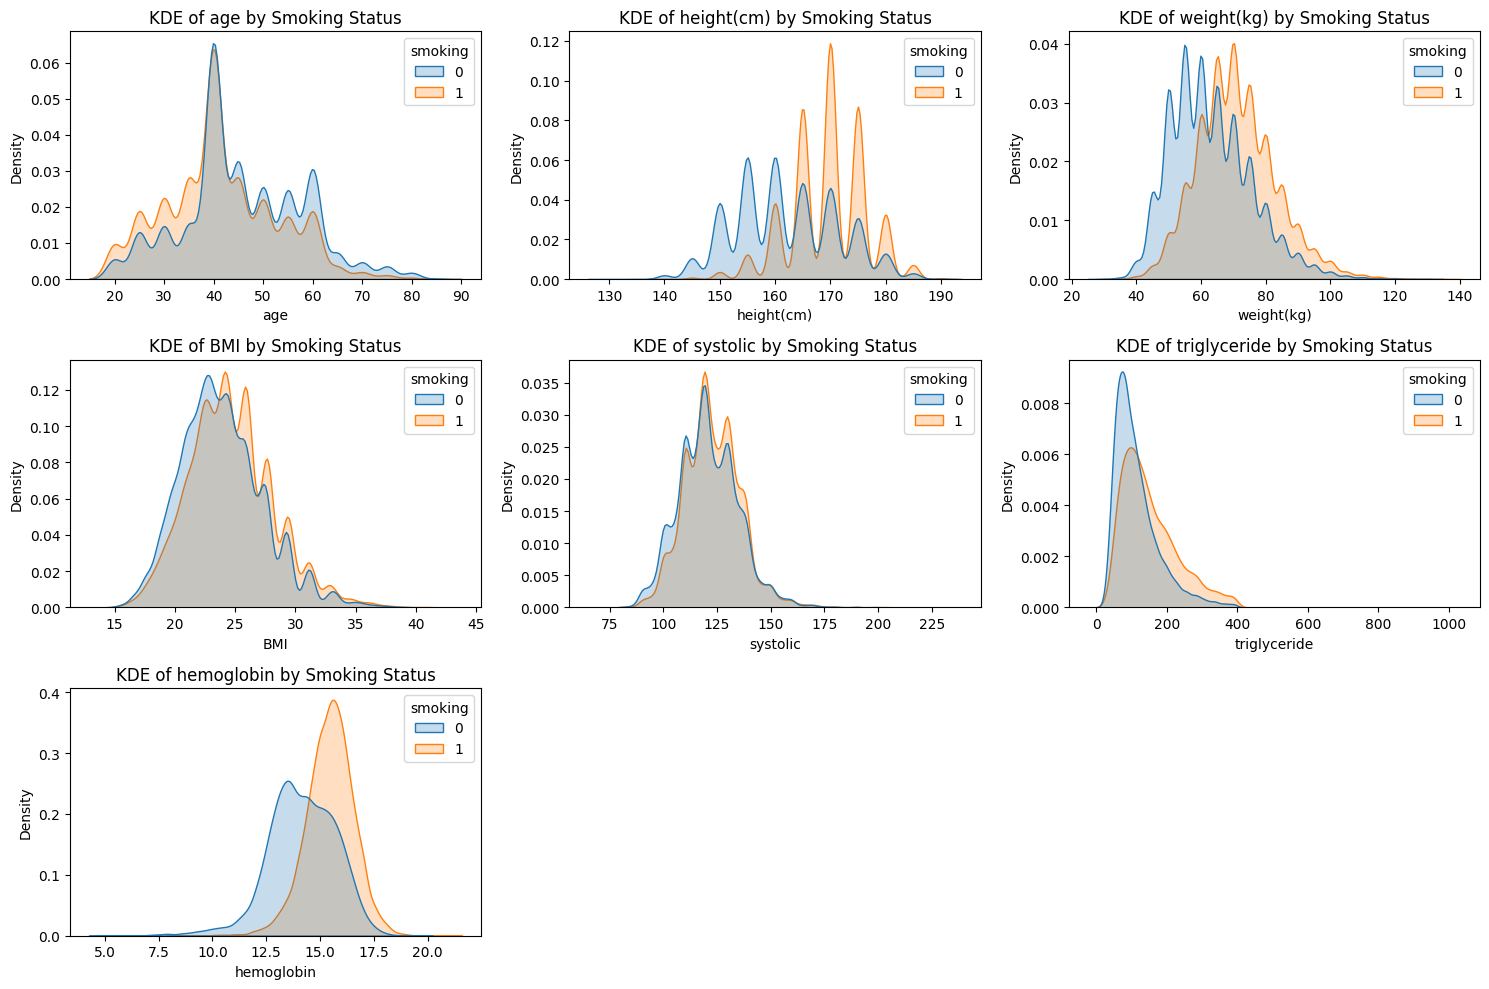

In [ ]:
plt.figure(figsize=(15, 10))
selected_features_for_kde = ['age', 'height(cm)', 'weight(kg)', 'BMI', 'systolic', 'triglyceride', 'hemoglobin']

for i, feature in enumerate(selected_features_for_kde):
    plt.subplot(3, 3, i + 1)
    sns.kdeplot(data=df_train, x=feature, hue='smoking', fill=True, common_norm=False)
    plt.title(f'KDE of {feature} by Smoking Status')
    plt.xlabel(feature)
    plt.ylabel('Density')

plt.tight_layout()
plt.show()

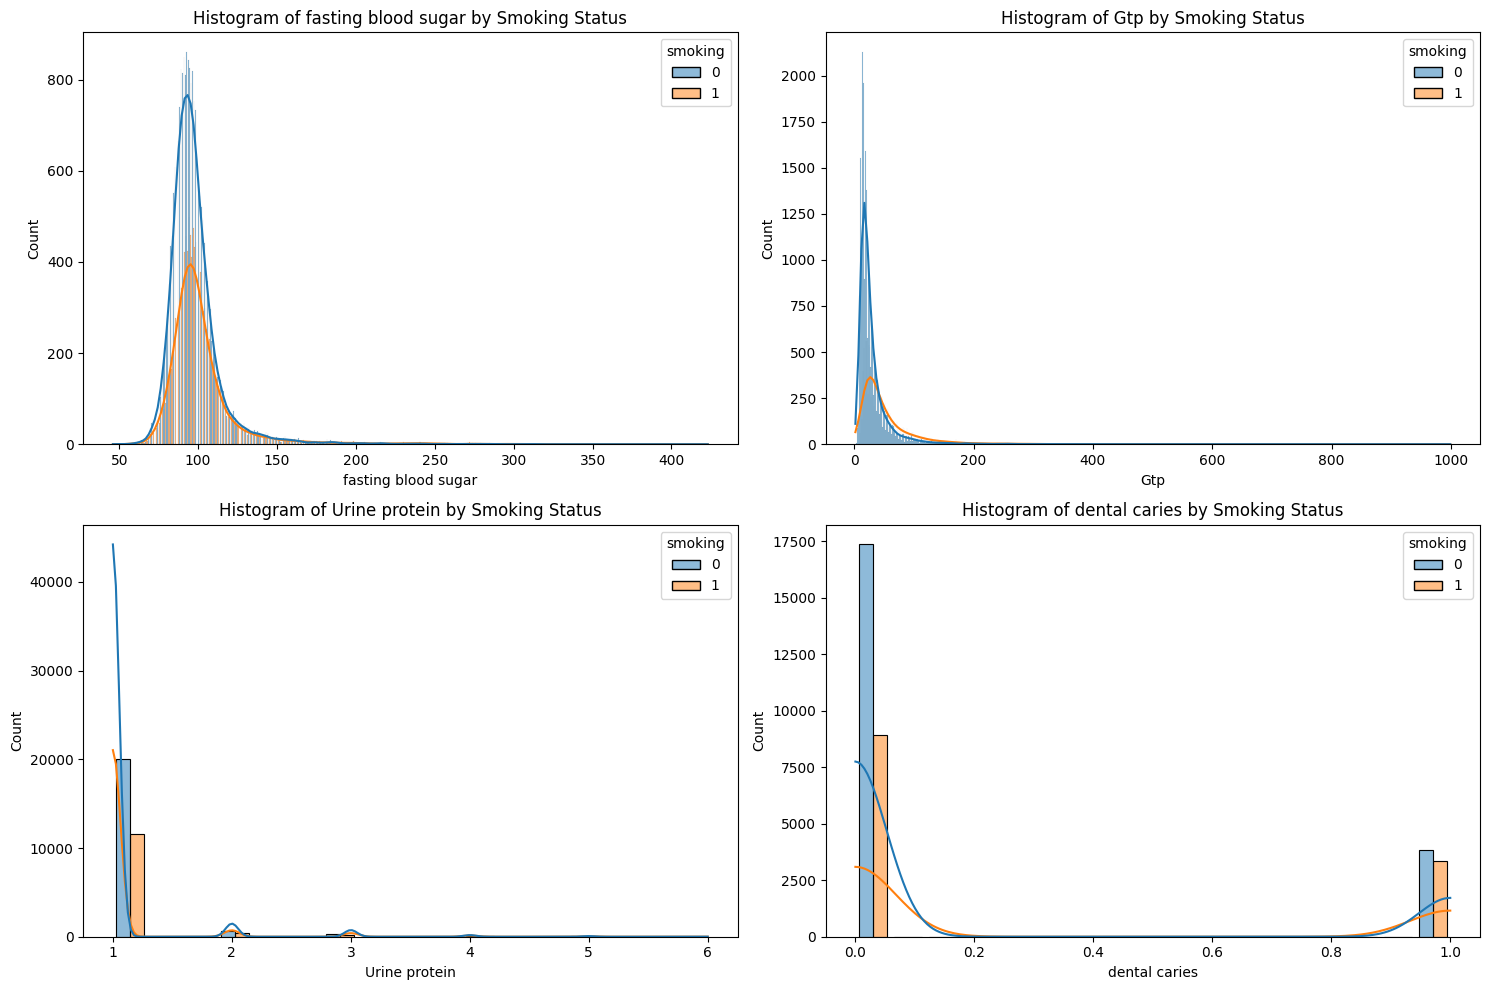

In [ ]:
plt.figure(figsize=(15, 10))
selected_features_for_hist = ['fasting blood sugar', 'Gtp', 'Urine protein', 'dental caries']

for i, feature in enumerate(selected_features_for_hist):
    plt.subplot(2, 2, i + 1)
    sns.histplot(data=df_train, x=feature, hue='smoking', multiple='dodge', shrink=0.8, kde=True)
    plt.title(f'Histogram of {feature} by Smoking Status')
    plt.xlabel(feature)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

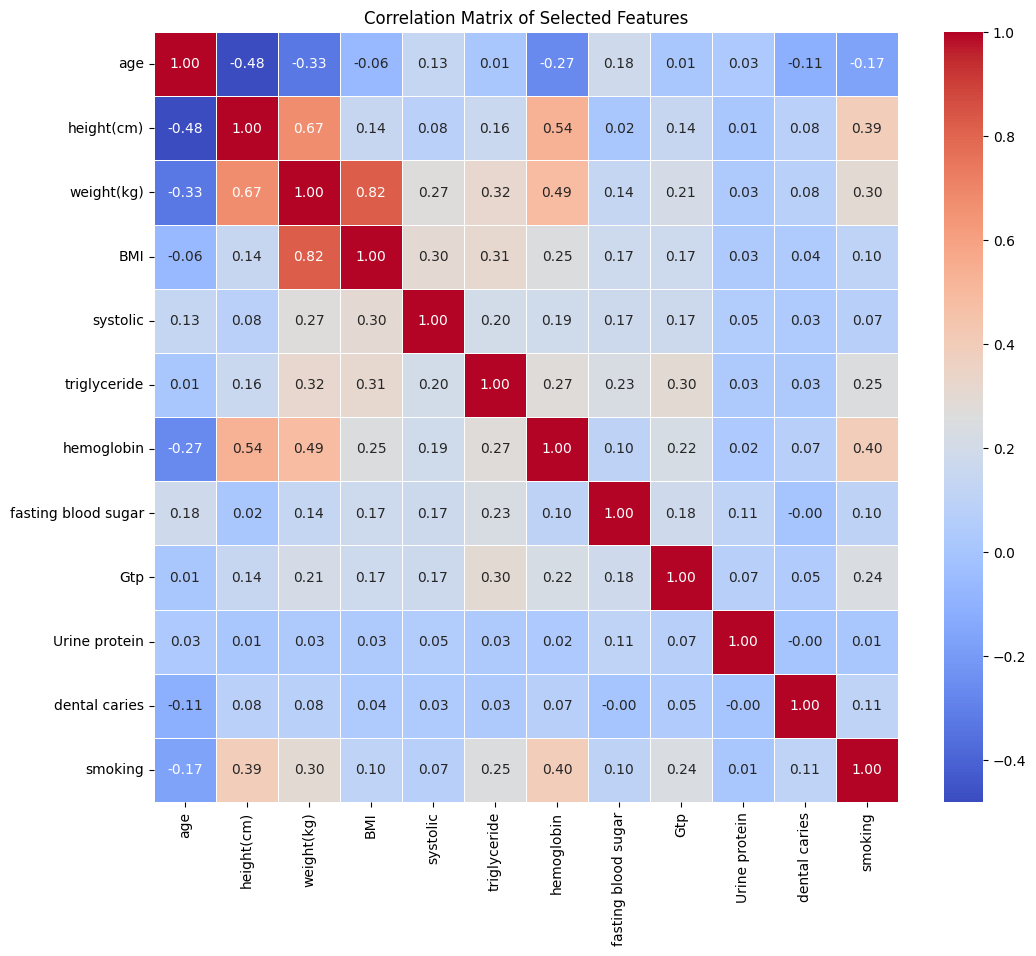

In [ ]:
plt.figure(figsize=(12, 10))

# Select a subset of features for the correlation heatmap for better readability
heatmap_features = ['age', 'height(cm)', 'weight(kg)', 'BMI', 'systolic', 'triglyceride', 'hemoglobin',
                    'fasting blood sugar', 'Gtp', 'Urine protein', 'dental caries', 'smoking']

correlation_matrix = df_train[heatmap_features].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Selected Features')
plt.show()

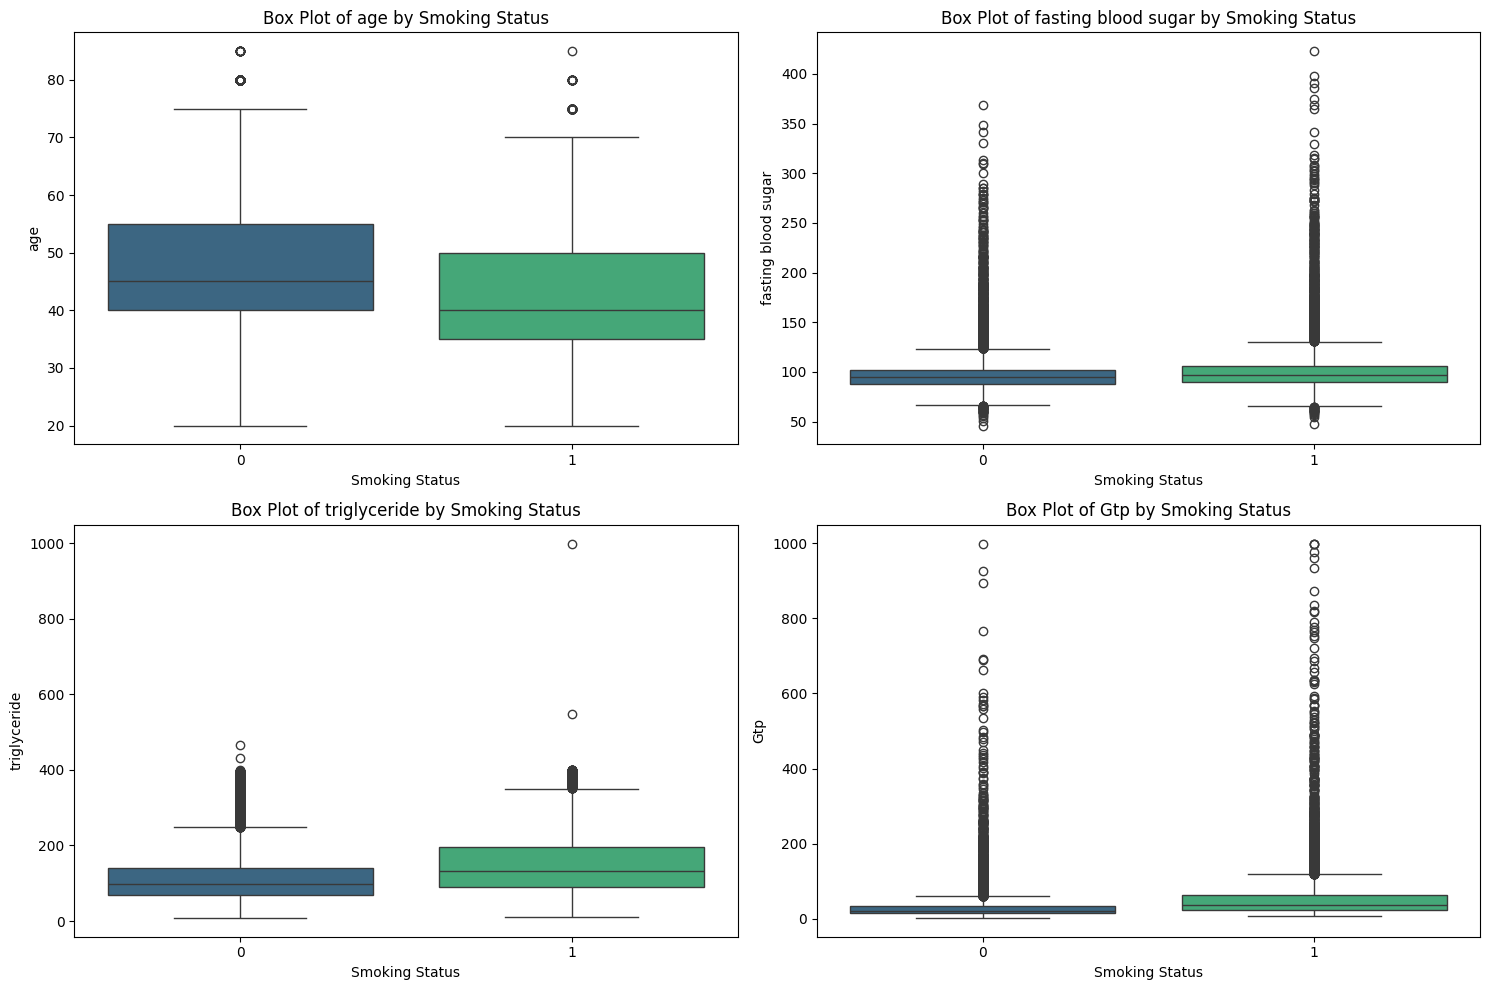

In [ ]:
plt.figure(figsize=(15, 10))
selected_features_for_boxplot = ['age', 'fasting blood sugar', 'triglyceride', 'Gtp']

for i, feature in enumerate(selected_features_for_boxplot):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=df_train, x='smoking', y=feature, palette='viridis')
    plt.title(f'Box Plot of {feature} by Smoking Status')
    plt.xlabel('Smoking Status')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

In [ ]:
%%time
# Drop missing values target column of the dataset...
categorical_features = ['hearing(left)', 'hearing(right)', 'Urine protein', 'dental caries']
numerical_features = [feat for feat in df_train.columns if feat not in categorical_features and feat not in ['smoking']]


CPU times: user 95 µs, sys: 4 µs, total: 99 µs
Wall time: 103 µs


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define features (X) and target (y)
X = df_train.drop('smoking', axis=1)
y = df_train['smoking']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numerical features
scaler = StandardScaler()

# Ensure 'numerical_features' is defined and contains only columns present in X_train
# Some columns might have been created by 'massive_feature' and might not be explicitly in the 'numerical_features' list if not updated.
# Re-evaluating numerical features from X_train to be safe.
current_numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()
X_train[current_numerical_features] = scaler.fit_transform(X_train[current_numerical_features])
X_test[current_numerical_features] = scaler.transform(X_test[current_numerical_features])

print("Data split and scaled successfully.")

# Initialize and train the SVM model
print("\nTraining SVM model...")
svm_model = SVC(kernel='rbf', random_state=42) # Using RBF kernel,
svm_model.fit(X_train, y_train)
print("SVM model training complete.")



Data split and scaled successfully.

Training SVM model...
SVM model training complete.


In [ ]:
# Make predictions on the test set
y_pred = svm_model.predict(X_test)

# Evaluate the model
print("\nSVM Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


SVM Model Evaluation:
Accuracy: 0.7471

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.81      0.80      4242
           1       0.66      0.65      0.65      2452

    accuracy                           0.75      6694
   macro avg       0.73      0.73      0.73      6694
weighted avg       0.75      0.75      0.75      6694


Confusion Matrix:
[[3419  823]
 [ 870 1582]]


## Perform Hyperparameter Tuning for SVM



In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 12.5 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.model_selection import cross_val_score

# Define the objective function for Optuna
def objective(trial):
    # Suggest hyperparameters for SVM
    C = trial.suggest_loguniform('C', 1e-3, 1e2) # C can be a wide range
    gamma = trial.suggest_loguniform('gamma', 1e-4, 1e-1) # gamma can be a wide range
    kernel = trial.suggest_categorical('kernel', ['rbf']) # Sticking to rbf as per original request

    # Initialize SVM model with suggested hyperparameters
    model = SVC(C=C, gamma=gamma, kernel=kernel, random_state=42)

    # Evaluate the model using cross-validation
    # Using cross_val_score for robustness, cv=3 as in original GridS earchCV
    accuracy = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1).mean()

    return accuracy

print("Starting Optuna hyperparameter tuning...")
# Create an Optuna study object and optimize the objective function
# 'maximize' direction because we want to maximize accuracy
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True) # You can adjust n_trials
print("Optuna hyperparameter tuning complete.")

# Print the best parameters and best score
print("\nBest parameters found by Optuna:", study.best_params)
print("Best cross-validation accuracy found by Optuna:", study.best_value)

[I 2025-12-10 16:08:51,593] A new study created in memory with name: no-name-bc0b7fba-2345-4a58-9300-cbe44da7e764


Starting Optuna hyperparameter tuning...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-10 16:27:39,955] Trial 0 finished with value: 0.6820679199514857 and parameters: {'C': 2.666637512901289, 'gamma': 0.0507058752033692, 'kernel': 'rbf'}. Best is trial 0 with value: 0.6820679199514857.
[I 2025-12-10 16:33:08,446] Trial 1 finished with value: 0.6502818321411935 and parameters: {'C': 0.004170731869030903, 'gamma': 0.0059221487137764905, 'kernel': 'rbf'}. Best is trial 0 with value: 0.6820679199514857.
[I 2025-12-10 16:37:25,113] Trial 2 finished with value: 0.750457612598304 and parameters: {'C': 32.10940141586881, 'gamma': 0.00030822999309253153, 'kernel': 'rbf'}. Best is trial 2 with value: 0.750457612598304.
[I 2025-12-10 16:51:35,714] Trial 3 finished with value: 0.714936739375266 and parameters: {'C': 14.275620974403166, 'gamma': 0.0076492394443742, 'kernel': 'rbf'}. Best is trial 2 with value: 0.750457612598304.
[I 2025-12-10 16:55:51,670] Trial 4 finished with value: 0.7479177542823493 and parameters: {'C': 0.813177207854731, 'gamma': 0.00083088539893190

KeyboardInterrupt: 

In [ ]:
# Get the best hyperparameters from Optuna study
# best_params_optuna = study.best_params
best_params_optuna = {'C': 32.10940141586881, 'gamma': 0.00030822999309253153, 'kernel': 'rbf'}
# Initialize a new SVM model with the best parameters found by Optuna
best_svm_model_optuna = SVC(C=best_params_optuna['C'],
                            gamma=best_params_optuna['gamma'],
                            kernel=best_params_optuna['kernel'],
                            random_state=42)

# Train the model with the best parameters on the full training data
best_svm_model_optuna.fit(X_train, y_train)

# Make predictions on the test set using the Optuna-tuned model
y_pred_optuna = best_svm_model_optuna.predict(X_test)

# Evaluate the Optuna-tuned model
print("\nOptuna-tuned SVM Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_optuna):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_optuna))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_optuna))


Optuna-tuned SVM Model Evaluation:
Accuracy: 0.7459

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80      4242
           1       0.65      0.65      0.65      2452

    accuracy                           0.75      6694
   macro avg       0.73      0.73      0.73      6694
weighted avg       0.75      0.75      0.75      6694


Confusion Matrix:
[[3404  838]
 [ 863 1589]]


## Logistic Regression Classification



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Define features (X) and target (y) - Re-defining these for context and to ensure execution
X = df_train.drop('smoking', axis=1)
y = df_train['smoking']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale numerical features
scaler = StandardScaler()

# Ensure 'numerical_features' is defined and contains only columns present in X_train
current_numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()
X_train[current_numerical_features] = scaler.fit_transform(X_train[current_numerical_features])
X_test[current_numerical_features] = scaler.transform(X_test[current_numerical_features])

print("Data split and scaled successfully.")

# 1. Initialize a Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')

print("Training Logistic Regression model...")
# 2. Train the model on the training data
log_reg_model.fit(X_train, y_train)
print("Logistic Regression model training complete.")

# 3. Make predictions on the test set
y_pred_lr = log_reg_model.predict(X_test)

# 4. Evaluate the model
print("\nLogistic Regression Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Data split and scaled successfully.
Training Logistic Regression model...
Logistic Regression model training complete.

Logistic Regression Model Evaluation:
Accuracy: 0.7451

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80      4242
           1       0.65      0.64      0.65      2452

    accuracy                           0.75      6694
   macro avg       0.73      0.72      0.72      6694
weighted avg       0.74      0.75      0.74      6694


Confusion Matrix:
[[3408  834]
 [ 872 1580]]


Visualizing the Logistic Regression Model Confusion Matrix...


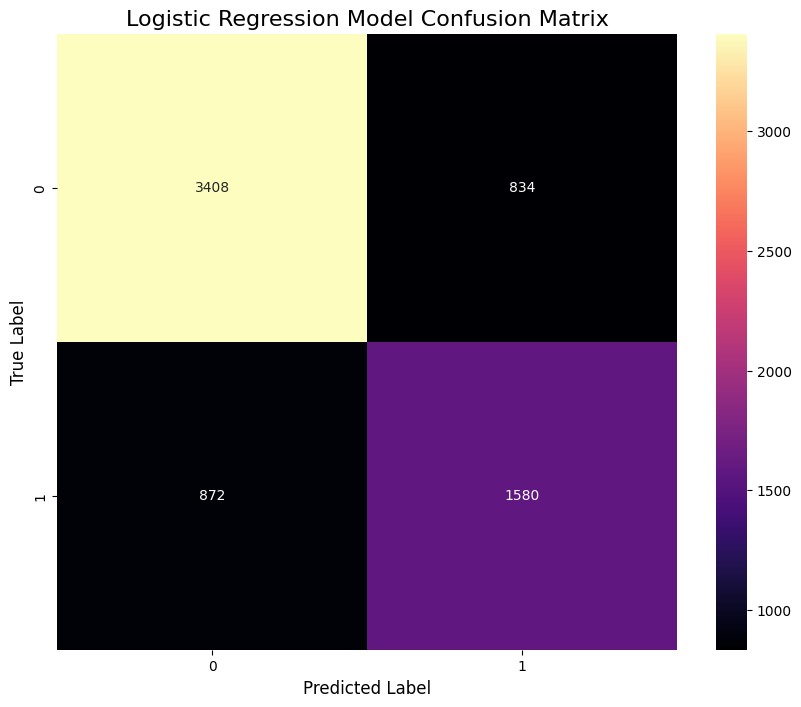

Confusion Matrix visualization complete.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the confusion matrix from the user-provided data
conf_matrix_nn = np.array(
    [[3408, 834],
 [ 872, 1580]]
)
y_test_adjusted_labels = np.arange(2)

print("Visualizing the Logistic Regression Model Confusion Matrix...")

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_nn, annot=True, fmt='d', cmap='magma',
            xticklabels=[str(i) for i in y_test_adjusted_labels],
            yticklabels=[str(i) for i in y_test_adjusted_labels])
plt.title('Logistic Regression Model Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

print("Confusion Matrix visualization complete.")

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

print("Keras components imported successfully.")

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 2. Create a Sequential model
model = Sequential()

# Get the number of features from X_train for input_shape
input_dim = X_train.shape[1]

# 3. Add a Dense layer with a suitable number of units and 'relu' activation
model.add(Dense(128, activation='relu', input_shape=(input_dim,))) # First hidden layer

# 4. Add one or more additional Dense hidden layers with 'relu' activation
model.add(Dense(64, activation='relu')) # Second hidden layer
model.add(Dense(32, activation='relu')) # Third hidden layer

# 5. Add a final Dense output layer with a single unit and 'sigmoid' activation for binary classification
model.add(Dense(1, activation='sigmoid'))

# 6. Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print the model summary to review its architecture
print("Neural Network model architecture:")
model.summary()

print("\nTraining Neural Network model...")
# 7. Train the compiled model
history = model.fit(
    X_train,
    y_train,
    epochs=20, # Number of epochs
    batch_size=64, # Batch size
    validation_split=0.2, # Use 20% of training data for validation
    verbose=1
)
print("Neural Network model training complete.")

Neural Network model architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,265 (169.00 KB)

 Trainable params: 43,265 (169.00 KB)

 Non-trainable params: 0 (0.00 B)


Training Neural Network model...
Epoch 1/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7118 - loss: 0.5260 - val_accuracy: 0.7494 - val_loss: 0.4790
Epoch 2/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7458 - loss: 0.4817 - val_accuracy: 0.7597 - val_loss: 0.4730
Epoch 3/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7538 - loss: 0.4719 - val_accuracy: 0.7565 - val_loss: 0.4696
Epoch 4/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7560 - loss: 0.4671 - val_accuracy: 0.7518 - val_loss: 0.4759
Epoch 5/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7658 - loss: 0.4624 - val_accuracy: 0.7507 - val_loss: 0.4751
Epoch 6/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7717 - loss: 0.4518 - val_accuracy: 0.7578 - val_loss: 0.4721
Epoch 7/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7673 - loss: 0.4564 - val_accuracy: 0.7542 - val_loss: 0.4716
Epoch 8/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7722

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

# Make predictions on the test set
y_pred_nn_prob = model.predict(X_test) # Get probabilities
y_pred_nn = (y_pred_nn_prob > 0.5).astype(int) # Convert probabilities to binary predictions

# Evaluate the model
print("\nNeural Network Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_nn):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nn))

210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

Neural Network Model Evaluation:
Accuracy: 0.7250

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.74      0.77      4242
           1       0.61      0.69      0.65      2452

    accuracy                           0.72      6694
   macro avg       0.71      0.72      0.71      6694
weighted avg       0.73      0.72      0.73      6694


Confusion Matrix:
[[3153 1089]
 [ 752 1700]]


Visualizing the Neural Network Confusion Matrix...


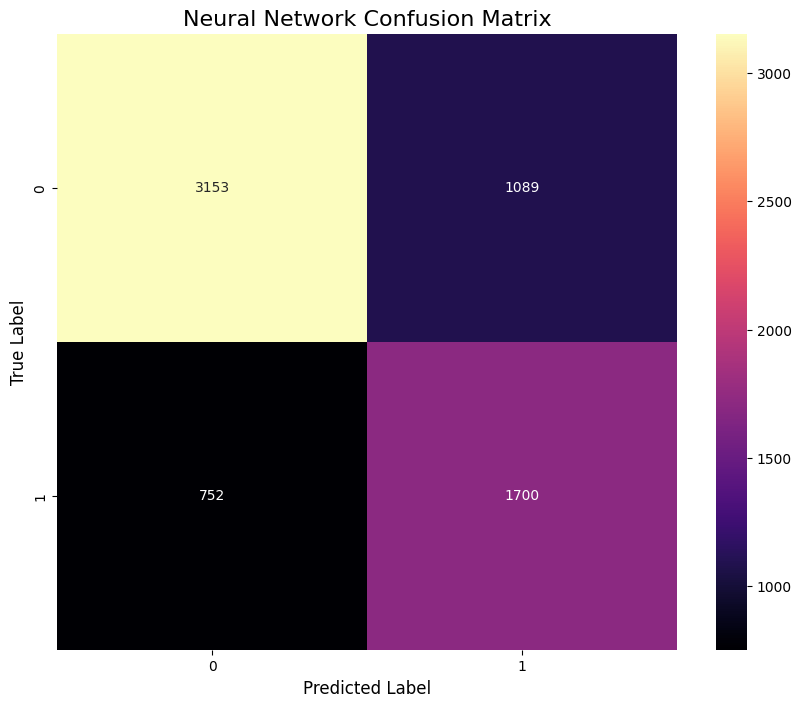

Confusion Matrix visualization complete.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

y_test_adjusted_labels = np.arange(2)

print("Visualizing the Neural Network Confusion Matrix...")

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_nn, annot=True, fmt='d', cmap='magma',
            xticklabels=[str(i) for i in y_test_adjusted_labels],
            yticklabels=[str(i) for i in y_test_adjusted_labels])
plt.title('Neural Network Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

print("Confusion Matrix visualization complete.")